# Install dan Import Library

In [ ]:
# =======================================================
# CELL 1: INSTALASI DAN IMPORT LIBRARY
# =======================================================

!pip install pandas numpy matplotlib seaborn wordcloud scikit-learn tqdm -q

import pandas as pd
import numpy as np
import re
import string
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from google.colab import drive
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

tqdm.pandas()

print("Library berhasil diimport.")

In [5]:
# =======================================================
# SEL 1 : INSTALL LIBRARY
# =======================================================

!pip install -q Sastrawi
!pip install -q emoji
!pip install -q wordcloud
!pip install -q nltk

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 12.3 MB/s eta 0:00:00


In [6]:
# =======================================================
# SEL 1a : IMPORT LIBRARY
# =======================================================

import re
import os
import emoji
import warnings
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from wordcloud import WordCloud

from collections import Counter

from sklearn.feature_extraction.text import CountVectorizer

warnings.filterwarnings("ignore")

plt.style.use("default")

SEED = 42

np.random.seed(SEED)

print("✅ Library berhasil diimport")

✅ Library berhasil diimport


# Mount Google Drive (folder penyimpanan hasil di google drive)

In [7]:
# =======================================================
# SEL 2 : MOUNT GOOGLE DRIVE
# =======================================================

from google.colab import drive

drive.mount('/content/drive')

PROJECT_DIR = "/content/drive/MyDrive/Skripsi_IndoBERT"

!mkdir -p "{PROJECT_DIR}/data"
!mkdir -p "{PROJECT_DIR}/models"
!mkdir -p "{PROJECT_DIR}/results"
!mkdir -p "{PROJECT_DIR}/logs"
!mkdir -p "{PROJECT_DIR}/analysis"

print("✅ Struktur folder berhasil dibuat")

Mounted at /content/drive
✅ Struktur folder berhasil dibuat


In [8]:
import os

print(os.listdir(PROJECT_DIR))

['data', 'models', 'results', 'logs', 'analysis']


# Load Dataset

In [9]:
# =======================================================
# SEL 4 : LOAD DATASET MENTAH
# =======================================================

data_url = "https://raw.githubusercontent.com/Miranita-ar/Skripsi-Gojek-App-Review/refs/heads/main/Data/ulasan_gojek.csv"

df = pd.read_csv(data_url)

print("Jumlah data awal :", len(df))
print("Jumlah kolom     :", len(df.columns))

display(df.head())

Jumlah data awal : 20000
Jumlah kolom     : 11


,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
0,5adef64a-687b-44cb-ae83-fccac29af5f8,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"saya sudah memakai aplikasi gojek 4 tahun,alha...",5,0,5.47.1,2026-02-03 00:57:36,NaN,NaN,5.47.1
1,ee4c68a5-56ba-4460-a302-8f6c1fe3b919,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,jarang ada diskon,5,0,5.48.2,2026-02-03 00:51:32,NaN,NaN,5.48.2
2,a1487729-8a06-4fb9-a99e-762150ba7438,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"makin berat aja apk, muter mulu mau beli tiket...",1,0,5.39.1,2026-02-03 00:37:37,"Hai Kak @Now You See Me Sony Handoko, mohon ma...",2026-02-03 01:46:54,5.39.1
3,37bb5ff1-22d2-49aa-afa9-4c0a88564a8e,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,aplikasi terbaik,5,0,5.47.1,2026-02-03 00:27:07,NaN,NaN,5.47.1
4,06afd47c-c6be-4839-9931-9d90b918b039,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"Di kasih limit di gopay pinjam 200rb,pengajuan...",2,0,5.48.2,2026-02-03 00:24:42,"Hai Kak Wirijaf, mohon maaf atas ketidaknyaman...",2026-02-03 01:42:50,5.48.2


In [10]:
# =======================================================
# SEL 5 : INFORMASI DATASET AWAL
# =======================================================

print("===== SHAPE DATA =====")
print(df.shape)

print("\n===== TIPE DATA =====")
display(df.dtypes)

print("\n===== MISSING VALUE =====")
display(df.isnull().sum())

print("\n===== DUPLIKAT REVIEW ID =====")
print(
    df["reviewId"].duplicated().sum()
)

===== SHAPE DATA =====
(20000, 11)

===== TIPE DATA =====


,0
reviewId,object
userName,object
userImage,object
content,object
score,int64
thumbsUpCount,int64
reviewCreatedVersion,object
at,object
replyContent,object
repliedAt,object



===== MISSING VALUE =====


,0
reviewId,0
userName,0
userImage,0
content,0
score,0
thumbsUpCount,0
reviewCreatedVersion,4373
at,0
replyContent,14483
repliedAt,14483



===== DUPLIKAT REVIEW ID =====
0


In [11]:
# =======================================================
# SEL 6 : CEK MISSING VALUE DAN DUPLIKAT
# =======================================================

jumlah_awal = len(df)

# missing value content

df = df.dropna(
    subset=["content"]
)

# duplikat reviewId

df = df.drop_duplicates(
    subset=["reviewId"],
    keep="first"
)

jumlah_akhir = len(df)

print("Jumlah data awal   :", jumlah_awal)
print("Jumlah data akhir  :", jumlah_akhir)
print("Data terhapus      :", jumlah_awal - jumlah_akhir)

Jumlah data awal   : 20000
Jumlah data akhir  : 20000
Data terhapus      : 0


# Labeling Sentimen

In [12]:
# =======================================================
# SEL 7 : LABELING MULTIKELAS
# =======================================================

def create_label(score):

    if score in [1, 2]:
        return 0

    elif score == 3:
        return 1

    else:
        return 2


df["label"] = df["score"].apply(
    create_label
)

print("Distribusi Label")

display(
    df["label"].value_counts().sort_index()
)

Distribusi Label


,count
label,
0,6129
1,759
2,13112


In [13]:
# =======================================================
# SEL 8 : SIMPAN DATASET HASIL LABELING
# =======================================================

label_path = (
    f"{PROJECT_DIR}/data/data_labeled_multiclass.csv"
)

df.to_csv(
    label_path,
    index=False
)

print("✅ Dataset labeling tersimpan")
print(label_path)

✅ Dataset labeling tersimpan
/content/drive/MyDrive/Skripsi_IndoBERT/data/data_labeled_multiclass.csv


# Informasi Data

## EDA Sebelum Pra-pemrosesan Data

In [14]:
# =======================================================
# SEL 9 : DISTRIBUSI RATING SEBELUM PRA-PEMROSESAN DATA
# =======================================================

rating_before = (
    df["score"]
    .value_counts()
    .sort_index()
)

display(rating_before)

,count
score,
1,5327
2,802
3,759
4,958
5,12154


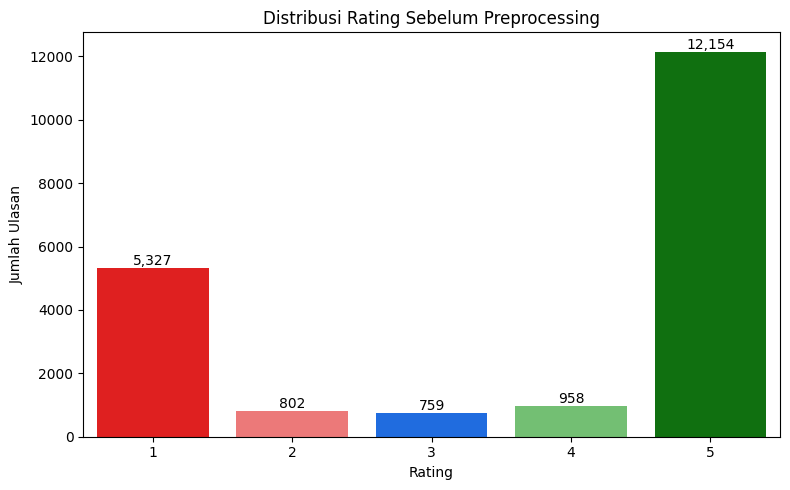

In [15]:
# =======================================================
# SEL 9A : DISTRIBUSI RATING (JUMLAH DATA)
# =======================================================

rating_before = (
    df["score"]
    .value_counts()
    .sort_index()
)

rating_colors = [
    "#FF0000",
    "#FF6666",
    "#0066FF",
    "#66CC66",
    "#008000"
]

plt.figure(figsize=(8,5))

ax = sns.barplot(
    x=rating_before.index,
    y=rating_before.values,
    palette=rating_colors
)

for i, v in enumerate(rating_before.values):

    ax.text(
        i,
        v,
        f"{v:,}",
        ha="center",
        va="bottom"
    )

plt.xlabel("Rating")
plt.ylabel("Jumlah Ulasan")

plt.title(
    "Distribusi Rating Sebelum Preprocessing"
)

plt.tight_layout()

plt.savefig(
    f"{PROJECT_DIR}/analysis/bar_rating_sebelum.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

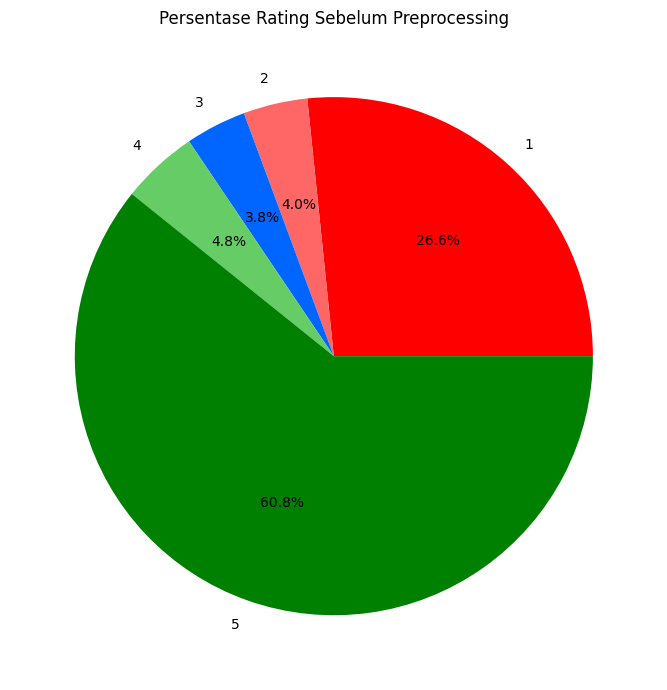

In [16]:
# =======================================================
# SEL 9B : PIE CHART RATING
# =======================================================

plt.figure(figsize=(7,7))

plt.pie(
    rating_before.values,
    labels=rating_before.index,
    autopct="%1.1f%%",
    colors=rating_colors
)

plt.title(
    "Persentase Rating Sebelum Preprocessing"
)

plt.tight_layout()

plt.savefig(
    f"{PROJECT_DIR}/analysis/pie_rating_sebelum.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [17]:
# =======================================================
# SEL 10 : DISTRIBUSI LABEL SEBELUM PRA-PEMROSESAN
# =======================================================

label_before = (
    df["label"]
    .value_counts()
    .sort_index()
)

display(label_before)

,count
label,
0,6129
1,759
2,13112


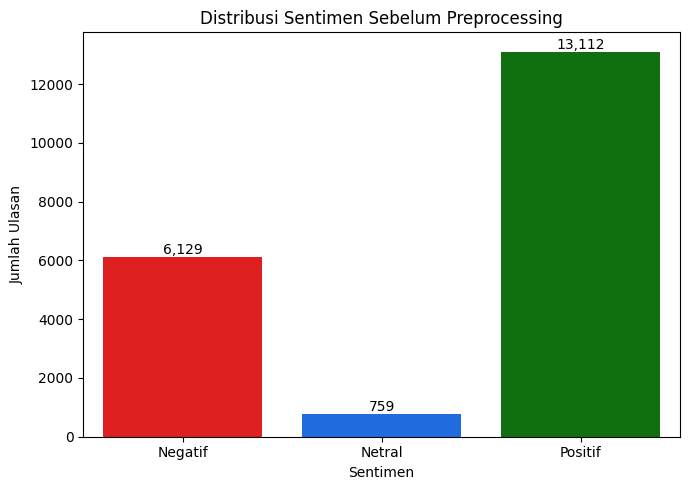

In [18]:
# =======================================================
# SEL 10A : DISTRIBUSI LABEL
# =======================================================

label_before = (
    df["label"]
    .value_counts()
    .sort_index()
)

label_names = [
    "Negatif",
    "Netral",
    "Positif"
]

sentiment_colors = [
    "#FF0000",
    "#0066FF",
    "#008000"
]

plt.figure(figsize=(7,5))

ax = sns.barplot(
    x=label_names,
    y=label_before.values,
    palette=sentiment_colors
)

for i, v in enumerate(label_before.values):

    ax.text(
        i,
        v,
        f"{v:,}",
        ha="center",
        va="bottom"
    )

plt.xlabel("Sentimen")
plt.ylabel("Jumlah Ulasan")

plt.title(
    "Distribusi Sentimen Sebelum Preprocessing"
)

plt.tight_layout()

plt.savefig(
    f"{PROJECT_DIR}/analysis/bar_label_sebelum.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

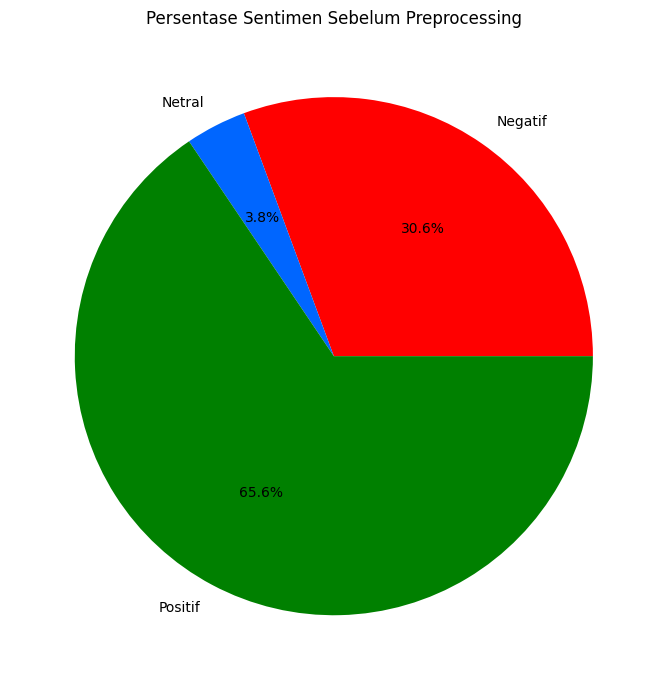

In [19]:
# =======================================================
# SEL 10B : PIE CHART LABEL
# =======================================================

plt.figure(figsize=(7,7))

plt.pie(
    label_before.values,
    labels=label_names,
    autopct="%1.1f%%",
    colors=sentiment_colors
)

plt.title(
    "Persentase Sentimen Sebelum Preprocessing"
)

plt.tight_layout()

plt.savefig(
    f"{PROJECT_DIR}/analysis/pie_label_sebelum.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Simpan hasil distribusi rating dan label sebelum prerpocessing

In [43]:
# =======================================================
# SIMPAN DISTRIBUSI SEBELUM PREPROCESSING
# =======================================================

rating_before.to_csv(
    f"{PROJECT_DIR}/data/rating_before.csv"
)

label_before.to_csv(
    f"{PROJECT_DIR}/data/label_before.csv"
)

print("✅ Distribusi sebelum preprocessing tersimpan")

✅ Distribusi sebelum preprocessing tersimpan


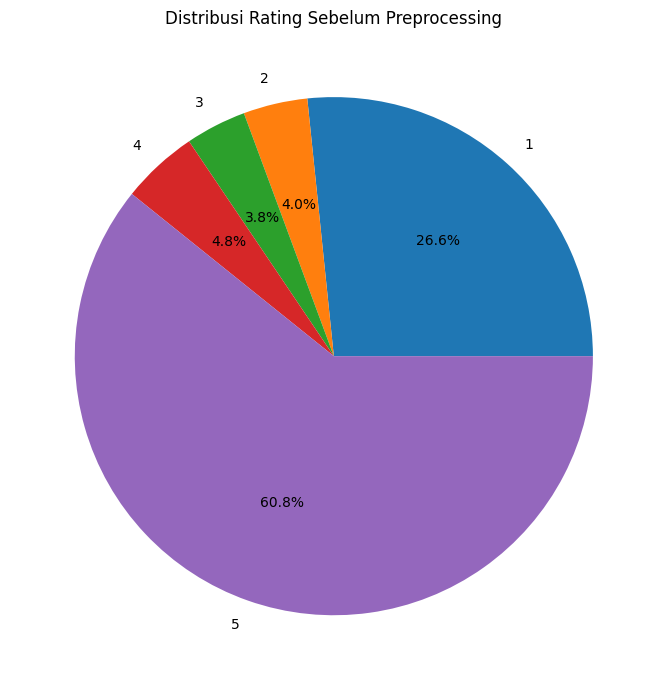

In [20]:
# =======================================================
# SEL 11 : PIE CHART RATING
# =======================================================

plt.figure(figsize=(7,7))

rating_before.plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.ylabel("")

plt.title(
    "Distribusi Rating Sebelum Preprocessing"
)

plt.tight_layout()

plt.savefig(
    f"{PROJECT_DIR}/analysis/pie_rating_sebelum.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

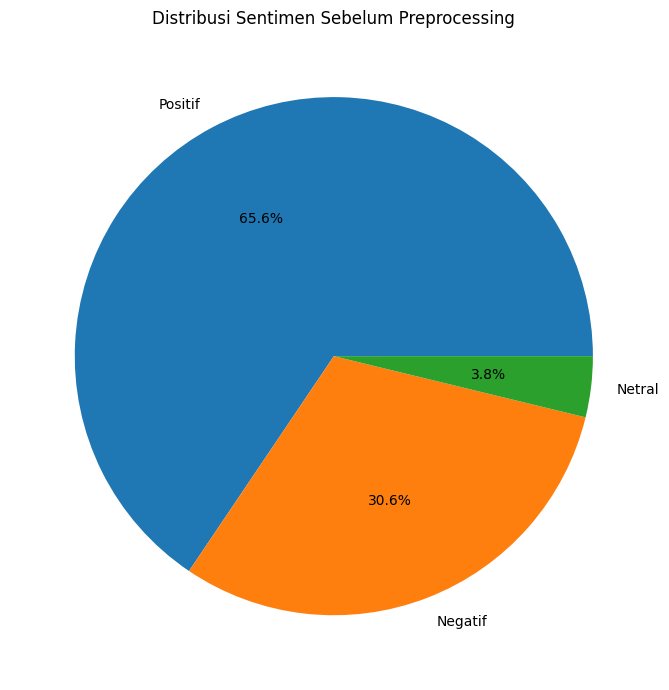

In [21]:
# =======================================================
# SEL 12 : PIE CHART LABEL
# =======================================================

label_mapping = {
    0:"Negatif",
    1:"Netral",
    2:"Positif"
}

label_before_named = (
    df["label"]
    .map(label_mapping)
    .value_counts()
)

plt.figure(figsize=(7,7))

label_before_named.plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.ylabel("")

plt.title(
    "Distribusi Sentimen Sebelum Preprocessing"
)

plt.tight_layout()

plt.savefig(
    f"{PROJECT_DIR}/analysis/pie_label_sebelum.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Pra-pemrosesan Data

## Case Folding:

Tujuan:

1. mengubah seluruh huruf menjadi lowercase
2. membuat kolom baru content_lower_case
3. kolom content asli tetap dipertahankan

In [22]:
# =======================================================
# SEL 13 : CASE FOLDING
# =======================================================

df["content_lower_case"] = (
    df["content"]
    .astype(str)
    .str.lower()
)

print("Contoh hasil case folding:\n")

display(
    df[
        [
            "content",
            "content_lower_case"
        ]
    ].head()
)

Contoh hasil case folding:



,content,content_lower_case
0,"saya sudah memakai aplikasi gojek 4 tahun,alha...","saya sudah memakai aplikasi gojek 4 tahun,alha..."
1,jarang ada diskon,jarang ada diskon
2,"makin berat aja apk, muter mulu mau beli tiket...","makin berat aja apk, muter mulu mau beli tiket..."
3,aplikasi terbaik,aplikasi terbaik
4,"Di kasih limit di gopay pinjam 200rb,pengajuan...","di kasih limit di gopay pinjam 200rb,pengajuan..."


## Cleansing:

hapus URL, hapus mention, hapus emoji, hapus newline, tanda baca (spasi), karakter khusus (spasi), angka dipertahankan, rapikan/hapus white space.

Hasil disimpan ke : content_clean

In [23]:
# =======================================================
# SEL 14 : CLEANSING
# =======================================================

import re
import emoji


def cleansing_text(text):

    text = str(text)

    # URL
    text = re.sub(
        r"http\S+|www\S+|https\S+",
        " ",
        text
    )

    # mention
    text = re.sub(
        r"@\w+",
        " ",
        text
    )

    # emoji
    text = emoji.replace_emoji(
        text,
        replace=""
    )

    # newline
    text = re.sub(
        r"[\n\r\t]",
        " ",
        text
    )

    # selain huruf, angka, dan spasi
    text = re.sub(
        r"[^a-zA-Z0-9\s]",
        " ",
        text
    )

    # spasi berlebih
    text = re.sub(
        r"\s+",
        " ",
        text
    ).strip()

    return text


df["content_clean"] = (
    df["content_lower_case"]
    .apply(cleansing_text)
)

print("Contoh hasil cleansing:\n")

display(
    df[
        [
            "content_lower_case",
            "content_clean"
        ]
    ].head()
)

Contoh hasil cleansing:



,content_lower_case,content_clean
0,"saya sudah memakai aplikasi gojek 4 tahun,alha...",saya sudah memakai aplikasi gojek 4 tahun alha...
1,jarang ada diskon,jarang ada diskon
2,"makin berat aja apk, muter mulu mau beli tiket...",makin berat aja apk muter mulu mau beli tiket krl
3,aplikasi terbaik,aplikasi terbaik
4,"di kasih limit di gopay pinjam 200rb,pengajuan...",di kasih limit di gopay pinjam 200rb pengajuan...


## Hapus Empty Text

In [24]:
# =======================================================
# SEL 15 : HAPUS EMPTY TEXT
# =======================================================

jumlah_sebelum = len(df)

df = df[
    df["content_clean"].str.strip() != ""
]

jumlah_sesudah = len(df)

print("Jumlah sebelum :", jumlah_sebelum)
print("Jumlah sesudah :", jumlah_sesudah)

print(
    "Data kosong terhapus :",
    jumlah_sebelum - jumlah_sesudah
)

Jumlah sebelum : 20000
Jumlah sesudah : 19794
Data kosong terhapus : 206


## Normalisasi slang

In [25]:
# =======================================================
# SEL 16 : LOAD KAMUS SLANG
# =======================================================

slang_url = (
    "https://raw.githubusercontent.com/"
    "Miranita-ar/"
    "Skripsi-Gojek-App-Review/"
    "refs/heads/main/Data/"
    "slang_ulasan%20gojek%20-%20slang1.csv"
)

slang_df = pd.read_csv(
    slang_url
)

print("Jumlah slang:")
print(len(slang_df))

display(
    slang_df.head()
)

Jumlah slang:
2253


,slang,normalisasi
0,100rb,100 ribu
1,10rb,10 ribu
2,10ribu,10 ribu
3,130rb,130 ribu
4,15mnt,15 menit


In [26]:
# =======================================================
# SEL 17 : DICTIONARY SLANG
# =======================================================

slang_dict = dict(
    zip(
        slang_df["slang"],
        slang_df["normalisasi"]
    )
)

print(
    "Jumlah pasangan slang:",
    len(slang_dict)
)

Jumlah pasangan slang: 2253


In [27]:
# =======================================================
# SEL 18 : NORMALISASI SLANG
# =======================================================

def normalize_text(text):

    words = text.split()

    normalized_words = [

        slang_dict[word]
        if word in slang_dict
        else word

        for word in words
    ]

    return " ".join(
        normalized_words
    )


df["content_normalisasi"] = (
    df["content_clean"]
    .apply(normalize_text)
)

print("Contoh hasil normalisasi:\n")

display(
    df[
        [
            "content_clean",
            "content_normalisasi"
        ]
    ].head()
)

Contoh hasil normalisasi:



,content_clean,content_normalisasi
0,saya sudah memakai aplikasi gojek 4 tahun alha...,saya sudah memakai aplikasi gojek 4 tahun alha...
1,jarang ada diskon,jarang ada diskon
2,makin berat aja apk muter mulu mau beli tiket krl,makin berat aja aplikasi muter terus mau beli ...
3,aplikasi terbaik,aplikasi terbaik
4,di kasih limit di gopay pinjam 200rb pengajuan...,di kasih limit di gopay pinjam 200 ribu pengaj...


## Hasil Pra-pemrosesan Data

In [28]:
# =======================================================
# SEL 19 : CEK HASIL PREPROCESSING
# =======================================================

display(
    df[
        [
            "score",
            "label",
            "content",
            "content_normalisasi"
        ]
    ].sample(
        10,
        random_state=42
    )
)

,score,label,content,content_normalisasi
17469,5,2,"makasih, lain kali banyakin promo nya dong🤭",makasih lain kali banyakin promo nya dong
18113,3,1,sorry saya hapus dulu akhir2 ini tidak bisa di...,sorry saya hapus dulu akhir-akhir ini tidak bi...
4062,5,2,bagus dan nyaman,bagus dan nyaman
3729,5,2,Gojek selalu membantu dan memberi kemudahan se...,gojek selalu membantu dan memberi kemudahan se...
17465,5,2,sangat membantu pagi pekerja,sangat membantu pagi pekerja
18707,5,2,Mantap sekali,mantap sekali
6059,4,2,"dulu sering dpt voucher, tapi knp skrg suka ga...",dulu sering dapat voucher tapi kenapa sekarang...
8104,1,0,nih kalo seandainya gak bakalan ada driver yan...,nih kalau seandainya gak bakalan ada driver ya...
16453,5,2,Wntarnarn,wntarnarn
7291,1,0,pesen gofood pake expres 1 jam lebih ga dpt2 p...,pesen gofood pakai express 1 jam lebih gak dap...


## Simpan Dataset Hasil Preprocessing

semua data hasil preprocessing di simpan di file Skripsi_IndoBERT: data

In [29]:
# =======================================================
# SEL 20 : SIMPAN DATASET PREPROCESSING
# =======================================================

save_path = (
    f"{PROJECT_DIR}/data/"
    "data_preprocessed_multiclass.csv"
)

df.to_csv(
    save_path,
    index=False
)

print("✅ Dataset preprocessing tersimpan")

print(save_path)

✅ Dataset preprocessing tersimpan
/content/drive/MyDrive/Skripsi_IndoBERT/data/data_preprocessed_multiclass.csv


In [30]:
# =======================================================
# SEL 20a : RELOAD DATASET HASIL PREPROCESSING
# =======================================================

save_path = (
    f"{PROJECT_DIR}/data/"
    "data_preprocessed_multiclass.csv"
)

# EDA Setelah Pra-pemrosesan Data

,count
score,
1,5321
2,801
3,757
4,951
5,11964


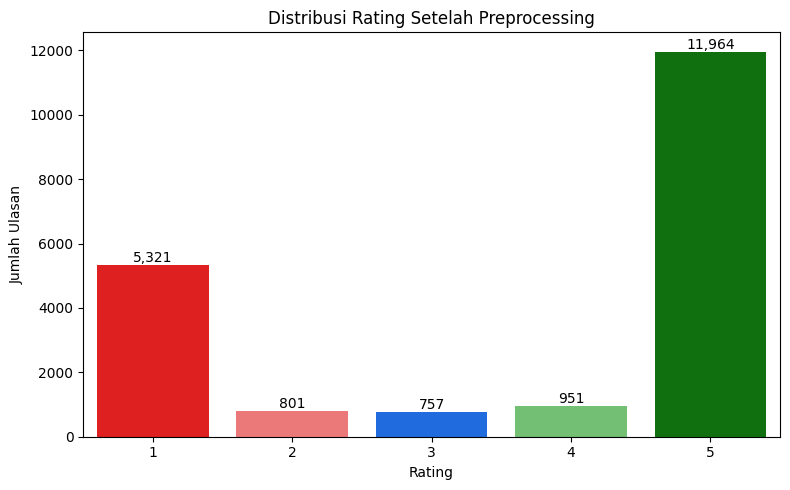

In [31]:
# =======================================================
# SEL 21 : DISTRIBUSI RATING SETELAH PREPROCESSING
# =======================================================

rating_after = (
    df["score"]
    .value_counts()
    .sort_index()
)

display(rating_after)

plt.figure(figsize=(8,5))

ax = sns.barplot(
    x=rating_after.index,
    y=rating_after.values,
    palette=rating_colors
)

for i, v in enumerate(rating_after.values):

    ax.text(
        i,
        v,
        f"{v:,}",
        ha="center",
        va="bottom"
    )

plt.title(
    "Distribusi Rating Setelah Preprocessing"
)

plt.xlabel("Rating")
plt.ylabel("Jumlah Ulasan")

plt.tight_layout()

plt.savefig(
    f"{PROJECT_DIR}/analysis/bar_rating_sesudah.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

,count
label,
0,6122
1,757
2,12915


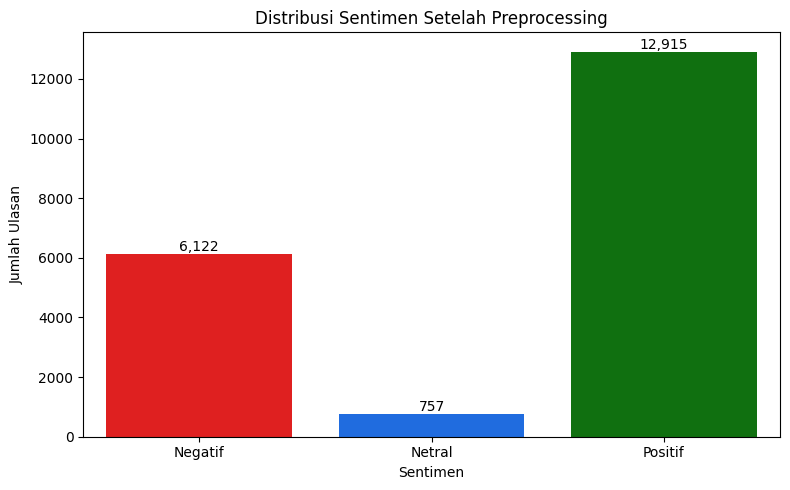

In [32]:
# =======================================================
# SEL 22 : DISTRIBUSI LABEL SETELAH PREPROCESSING
# =======================================================

label_after = (
    df["label"]
    .value_counts()
    .sort_index()
)

display(label_after)

plt.figure(figsize=(8,5))

ax = sns.barplot(
    x=["Negatif","Netral","Positif"],
    y=label_after.values,
    palette=sentiment_colors
)

for i, v in enumerate(label_after.values):

    ax.text(
        i,
        v,
        f"{v:,}",
        ha="center",
        va="bottom"
    )

plt.title(
    "Distribusi Sentimen Setelah Preprocessing"
)

plt.xlabel("Sentimen")
plt.ylabel("Jumlah Ulasan")

plt.tight_layout()

plt.savefig(
    f"{PROJECT_DIR}/analysis/bar_sentimen_sesudah.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [33]:
# =======================================================
# SEL 23 : PERUBAHAN JUMLAH RATING
# =======================================================

rating_comparison = pd.DataFrame({

    "Sebelum": rating_before,
    "Sesudah": rating_after

}).fillna(0)

rating_comparison["Berkurang"] = (

    rating_comparison["Sebelum"]
    -
    rating_comparison["Sesudah"]

)

display(rating_comparison)

rating_comparison.to_csv(
    f"{PROJECT_DIR}/analysis/perubahan_rating.csv"
)

,Sebelum,Sesudah,Berkurang
score,,,
1,5327,5321,6
2,802,801,1
3,759,757,2
4,958,951,7
5,12154,11964,190


In [34]:
# =======================================================
# SEL 24 : PERUBAHAN JUMLAH LABEL
# =======================================================

label_comparison = pd.DataFrame({

    "Sebelum": label_before,
    "Sesudah": label_after

}).fillna(0)

label_comparison["Berkurang"] = (

    label_comparison["Sebelum"]
    -
    label_comparison["Sesudah"]

)

display(label_comparison)

label_comparison.to_csv(
    f"{PROJECT_DIR}/analysis/perubahan_label.csv"
)

,Sebelum,Sesudah,Berkurang
label,,,
0,6129,6122,7
1,759,757,2
2,13112,12915,197


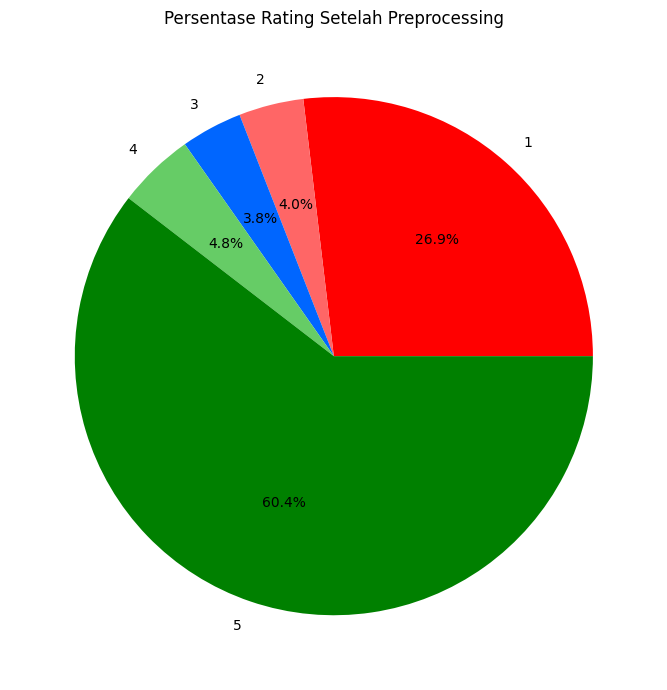

In [35]:
# =======================================================
# SEL 25 : PIE CHART RATING SETELAH PREPROCESSING
# =======================================================

plt.figure(figsize=(7,7))

plt.pie(
    rating_after.values,
    labels=rating_after.index,
    autopct="%1.1f%%",
    colors=rating_colors
)

plt.title(
    "Persentase Rating Setelah Preprocessing"
)

plt.tight_layout()

plt.savefig(
    f"{PROJECT_DIR}/analysis/pie_rating_sesudah.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

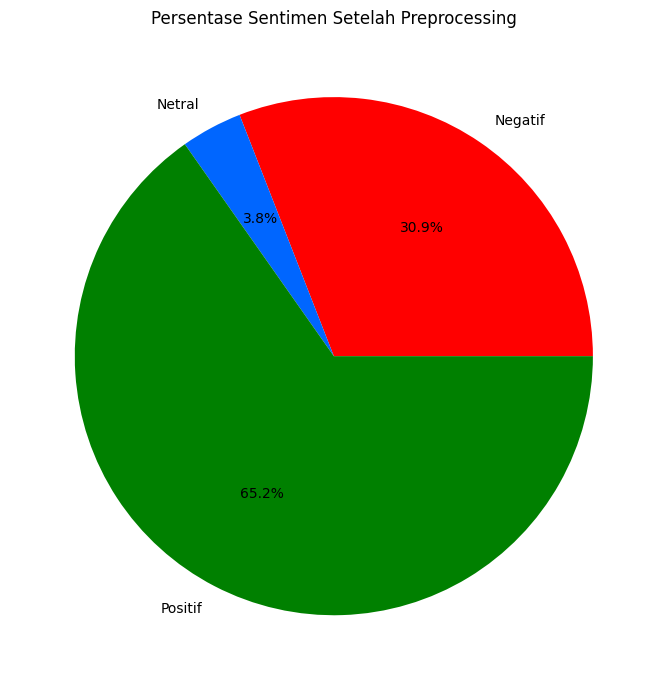

In [36]:
# =======================================================
# SEL 26 : PIE CHART SENTIMEN SETELAH PREPROCESSING
# =======================================================

plt.figure(figsize=(7,7))

plt.pie(
    label_after.values,
    labels=["Negatif","Netral","Positif"],
    autopct="%1.1f%%",
    colors=sentiment_colors
)

plt.title(
    "Persentase Sentimen Setelah Preprocessing"
)

plt.tight_layout()

plt.savefig(
    f"{PROJECT_DIR}/analysis/pie_sentimen_sesudah.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Simpan Hasil Distribusi Setelah Preprocessing

In [44]:
# =======================================================
# SIMPAN DISTRIBUSI SETELAH PREPROCESSING
# =======================================================

rating_after.to_csv(
    f"{PROJECT_DIR}/data/rating_after.csv"
)

label_after.to_csv(
    f"{PROJECT_DIR}/data/label_after.csv"
)

print("✅ Distribusi sesudah preprocessing tersimpan")

✅ Distribusi sesudah preprocessing tersimpan


=== DISTRIBUSI ULASAN TIAP BULAN ===


,at,jumlah_ulasan,bulan_tahun
0,2025-08-31,759,Aug 2025
1,2025-09-30,3562,Sep 2025
2,2025-10-31,3789,Oct 2025
3,2025-11-30,3686,Nov 2025
4,2025-12-31,3794,Dec 2025
5,2026-01-31,3881,Jan 2026
6,2026-02-28,323,Feb 2026


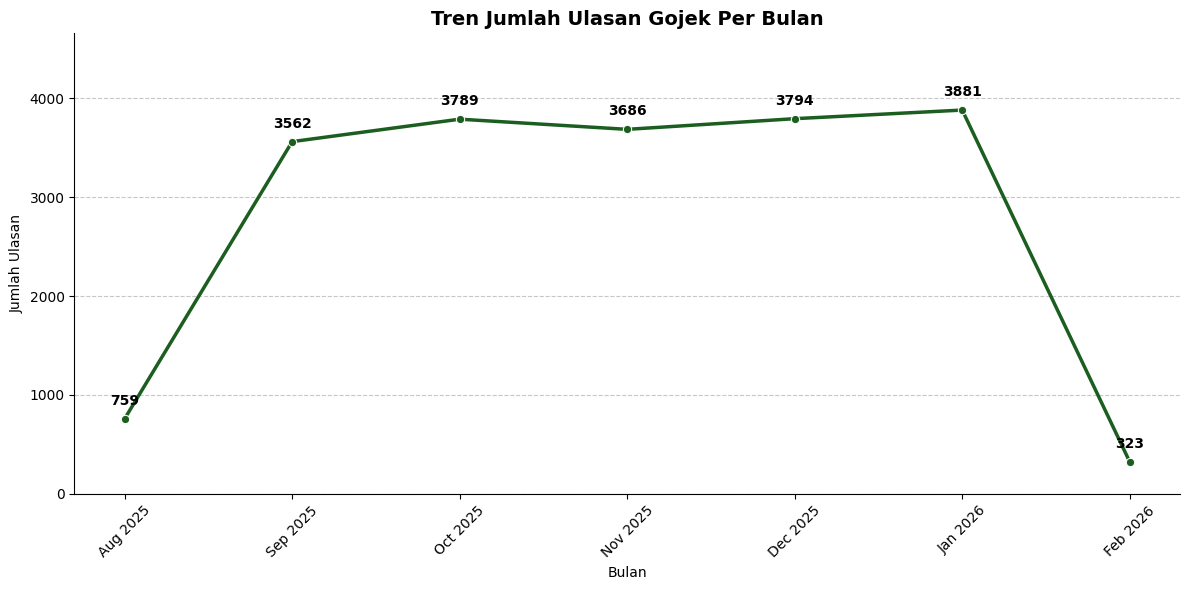

In [38]:
# =======================================================
# SEL 27 : TREN JUMLAH ULASAN PER BULAN
# =======================================================

df["at"] = pd.to_datetime(df["at"])

df_monthly = (
    df
    .resample(
        "M",
        on="at"
    )
    .size()
    .reset_index(
        name="jumlah_ulasan"
    )
)

df_monthly["bulan_tahun"] = (
    df_monthly["at"]
    .dt
    .strftime("%b %Y")
)

print("=== DISTRIBUSI ULASAN TIAP BULAN ===")

display(df_monthly)

plt.figure(figsize=(12,6))

sns.lineplot(
    data=df_monthly,
    x="bulan_tahun",
    y="jumlah_ulasan",
    marker="o",
    linewidth=2.5,
    color="#1B5E20"
)

for i, row in df_monthly.iterrows():

    plt.annotate(
        f"{row['jumlah_ulasan']}",
        (
            row["bulan_tahun"],
            row["jumlah_ulasan"]
        ),
        textcoords="offset points",
        xytext=(0,10),
        ha="center",
        fontsize=10,
        fontweight="bold"
    )

plt.title(
    "Tren Jumlah Ulasan Gojek Per Bulan",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Bulan")
plt.ylabel("Jumlah Ulasan")

plt.xticks(rotation=45)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.7
)

plt.ylim(
    0,
    df_monthly["jumlah_ulasan"].max() * 1.2
)

sns.despine()

plt.tight_layout()

plt.savefig(
    f"{PROJECT_DIR}/analysis/tren_ulasan_per_bulan.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

=== DISTRIBUSI SENTIMEN PER BULAN ===


,Negatif,Netral,Positif
year_month,,,
Aug 2025,189,24,546
Sep 2025,916,128,2518
Oct 2025,1135,158,2496
Nov 2025,1142,119,2425
Dec 2025,1277,153,2364
Jan 2026,1351,154,2376
Feb 2026,112,21,190


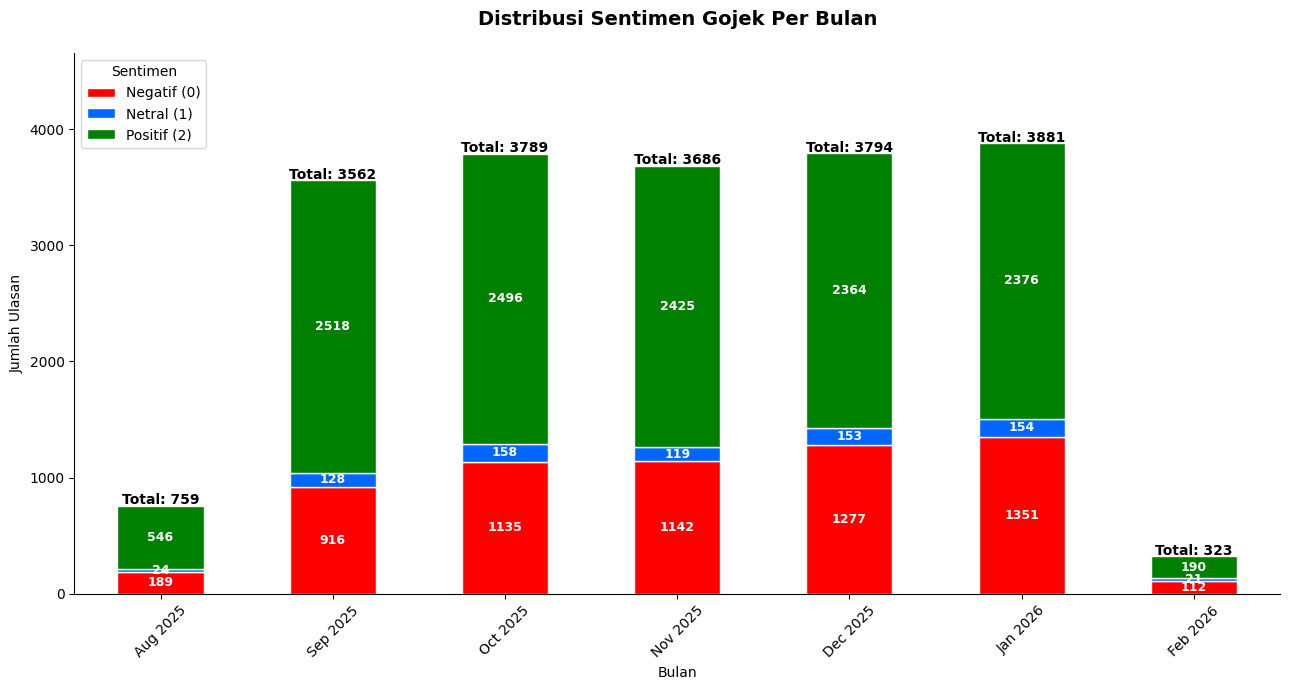

In [46]:
# =======================================================
# SEL 28 : DISTRIBUSI SENTIMEN PER BULAN
# =======================================================

import matplotlib.pyplot as plt
import seaborn as sns

# Pastikan datetime

df["at"] = pd.to_datetime(
    df["at"]
)

# Buat bulan-tahun

df["year_month"] = (
    df["at"]
    .dt
    .to_period("M")
)

# Kelompokkan bulan dan label

df_monthly_sentiment = (
    df
    .groupby(
        [
            "year_month",
            "label"
        ]
    )
    .size()
    .unstack(fill_value=0)
)

# rename kolom

df_monthly_sentiment.columns = [
    "Negatif",
    "Netral",
    "Positif"
]

# index lebih cantik

df_monthly_sentiment.index = (
    df_monthly_sentiment.index
    .strftime("%b %Y")
)

print(
    "=== DISTRIBUSI SENTIMEN PER BULAN ==="
)

display(
    df_monthly_sentiment
)

# =====================================================
# VISUALISASI
# =====================================================

ax = df_monthly_sentiment.plot(
    kind="bar",
    stacked=True,
    figsize=(13,7),
    color=[
        "#FF0000",  # negatif
        "#0066FF",  # netral
        "#008000"   # positif
    ],
    edgecolor="white"
)

# jumlah tiap sentimen

for p in ax.patches:

    width = p.get_width()

    height = p.get_height()

    x, y = p.get_xy()

    if height > 0:

        ax.annotate(
            f"{int(height)}",
            (
                x + width/2,
                y + height/2
            ),
            ha="center",
            va="center",
            fontsize=9,
            color="white",
            fontweight="bold"
        )

# total tiap bulan

totals = (
    df_monthly_sentiment
    .sum(axis=1)
)

for i, total in enumerate(totals):

    ax.text(
        i,
        total + 10,
        f"Total: {int(total)}",
        ha="center",
        fontsize=10,
        fontweight="bold",
        color="black"
    )

plt.title(
    "Distribusi Sentimen Gojek Per Bulan",
    fontsize=14,
    fontweight="bold",
    pad=20
)

plt.xlabel("Bulan")

plt.ylabel("Jumlah Ulasan")

plt.xticks(rotation=45)

plt.legend(
    [
        "Negatif (0)",
        "Netral (1)",
        "Positif (2)"
    ],
    title="Sentimen",
    loc="upper left"
)

plt.ylim(
    0,
    totals.max() * 1.2
)

sns.despine()

plt.tight_layout()

plt.savefig(
    f"{PROJECT_DIR}/analysis/distribusi_sentimen_per_bulan.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Penghapusan stopword tidak diterapkan pada data yang digunakan untuk pelatihan model karena model Transformer mampu memanfaatkan konteks kalimat secara utuh. Namun, untuk keperluan visualisasi WordCloud dan analisis Bigram, stopword dihilangkan agar kata-kata yang ditampilkan lebih informatif dan merepresentasikan topik utama yang dibahas dalam ulasan

In [64]:
# =======================================================
# SEL 28a : STOPWORD REMOVAL KHUSUS VISUALISASI
# =======================================================

from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

factory = StopWordRemoverFactory()

stopwords_id = set(
    factory.get_stop_words()
)

# tambah stopword yang sering muncul namun tidak informatif

custom_stopwords = {
    "nya",
    "aja",
    "sih",
    "dong",
    "nih",
    "kak",
    "min",
    "bang",
    "deh",
    "ya",
    "yg",
    "dan",
    "gak",
    "nggak"
}

stopwords_id.update(
    custom_stopwords
)

def remove_stopword_visualisasi(text):

    words = text.split()

    words = [
        word
        for word in words
        if word not in stopwords_id
    ]

    return " ".join(words)

df["content_visualisasi"] = (
    df["content_normalisasi"]
    .astype(str)
    .apply(remove_stopword_visualisasi)
)

print("Stopword removal khusus visualisasi selesai")

Stopword removal khusus visualisasi selesai


## Word Cloud

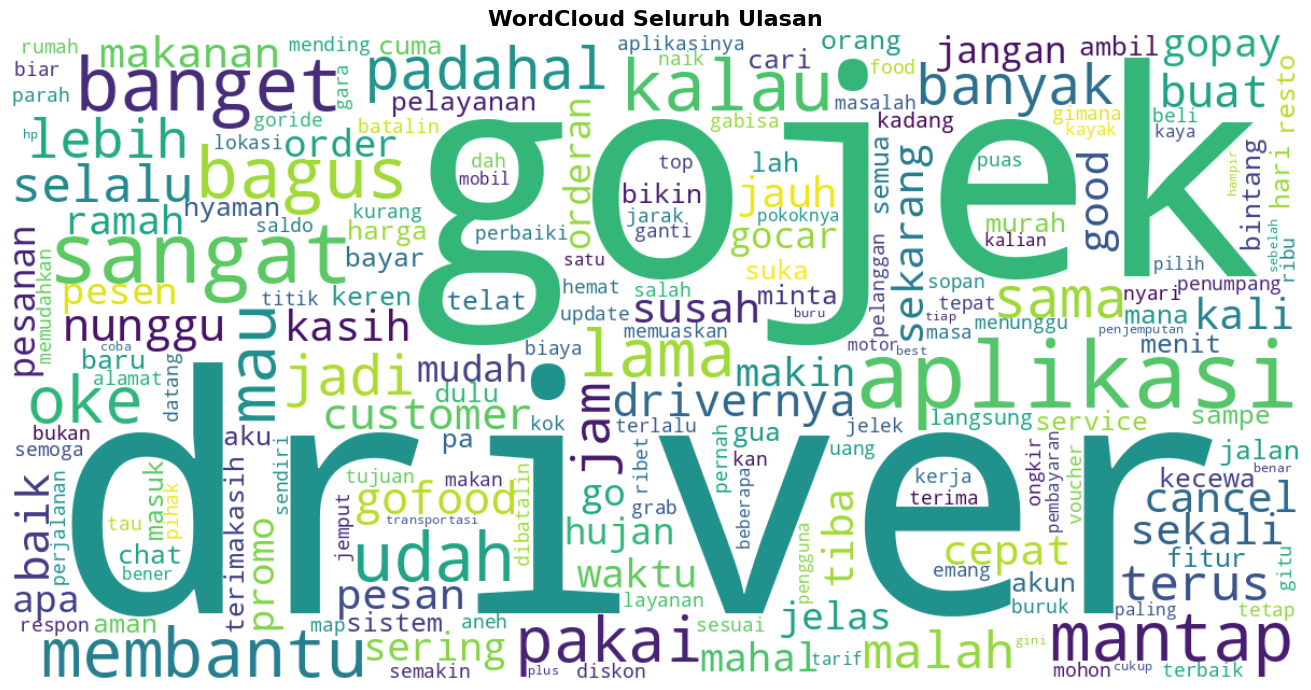

In [65]:
# =======================================================
# SEL 29 : WORDCLOUD KESELURUHAN
# =======================================================

from wordcloud import WordCloud
import matplotlib.pyplot as plt

text_all = " ".join(
    df["content_visualisasi"]
)

wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color="white",
    collocations=False,
    max_words=200
).generate(text_all)

plt.figure(figsize=(14,7))

plt.imshow(
    wordcloud,
    interpolation="bilinear"
)

plt.axis("off")

plt.title(
    "WordCloud Seluruh Ulasan",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()

plt.savefig(
    f"{PROJECT_DIR}/analysis/wordcloud_keseluruhan.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

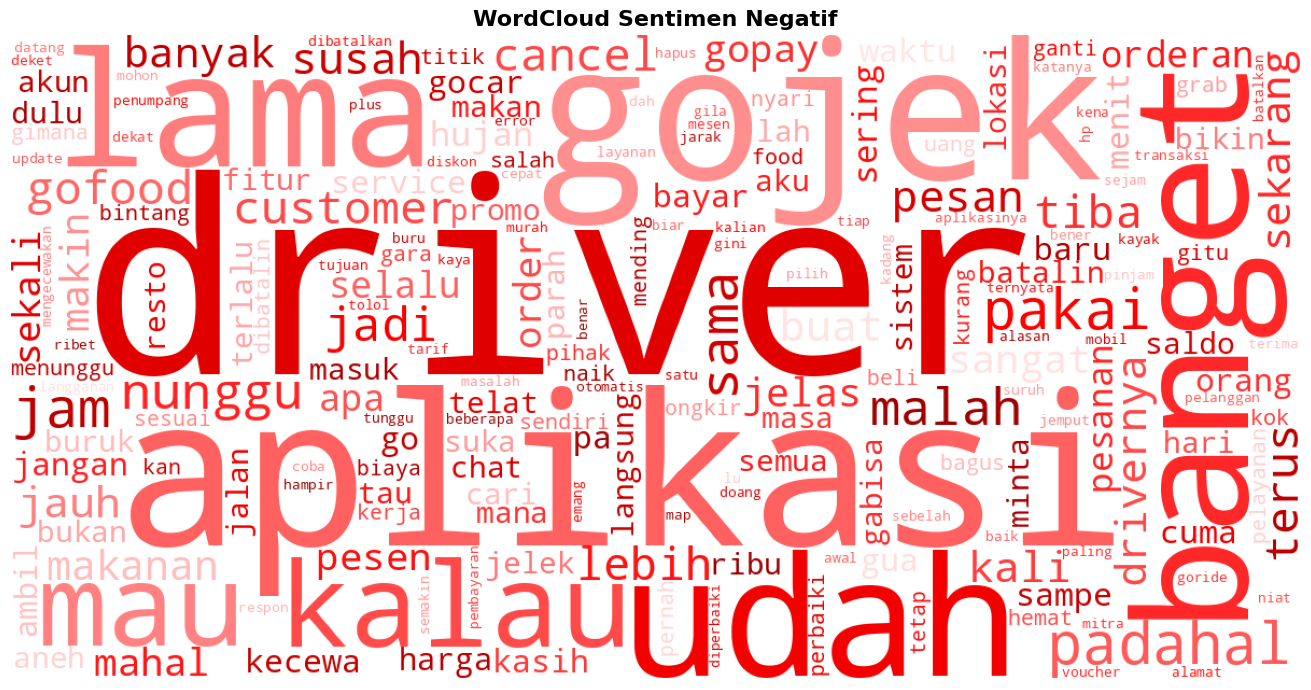

In [66]:
# =======================================================
# SEL 30 : WORDCLOUD NEGATIF
# =======================================================

from wordcloud import WordCloud
from matplotlib.colors import LinearSegmentedColormap

negatif_text = " ".join(
    df[df["label"] == 0]["content_visualisasi"].astype(str)
)

red_map = LinearSegmentedColormap.from_list(
    "red_map",
    [
        "#FFE5E5",
        "#FF6666",
        "#FF0000",
        "#990000"
    ]
)

wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color="white",
    collocations=False,
    max_words=200,
    colormap=red_map
).generate(negatif_text)

plt.figure(figsize=(14,7))

plt.imshow(wordcloud)

plt.axis("off")

plt.title(
    "WordCloud Sentimen Negatif",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()

plt.savefig(
    f"{PROJECT_DIR}/analysis/wordcloud_negatif.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

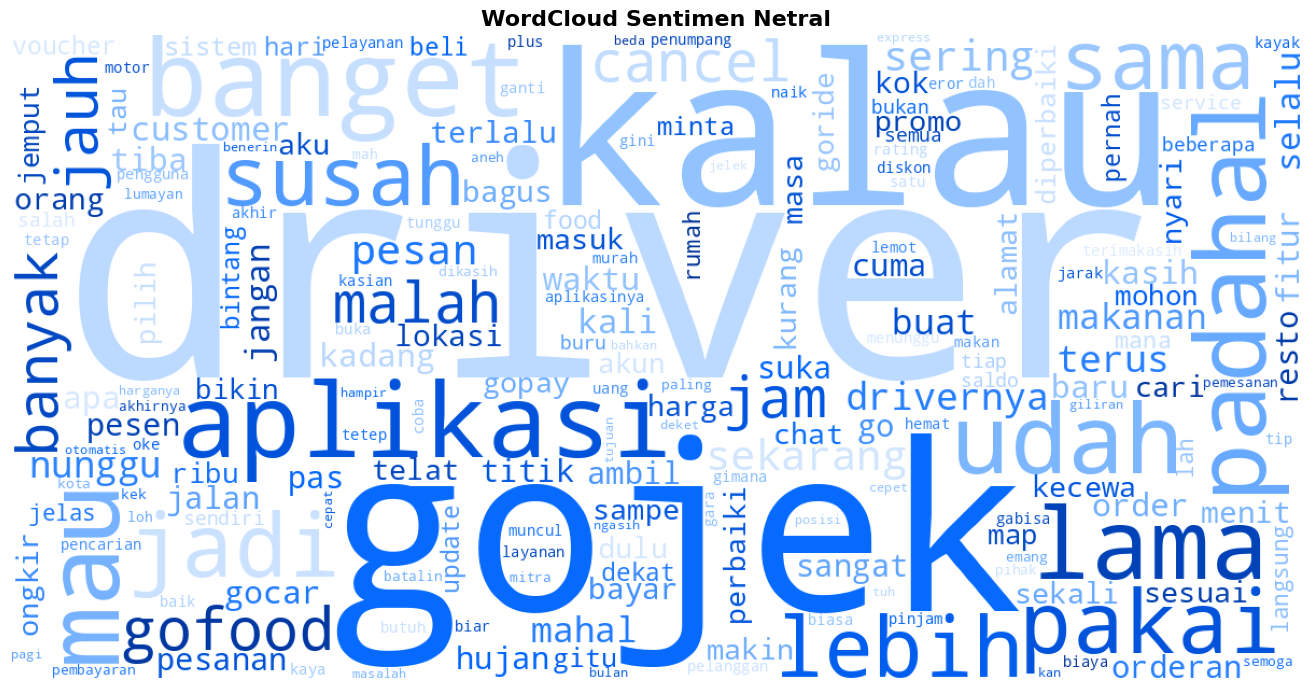

In [69]:
# =======================================================
# SEL 31 : WORDCLOUD NETRAL
# =======================================================

from matplotlib.colors import LinearSegmentedColormap

netral_text = " ".join(
    df[df["label"] == 1]["content_visualisasi"].astype(str)
)

blue_map = LinearSegmentedColormap.from_list(
    "blue_map",
    [
        "#DCEBFF",
        "#7DB7FF",
        "#0066FF",
        "#003399"
    ]
)

wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color="white",
    collocations=False,
    max_words=200,
    colormap=blue_map
).generate(netral_text)

plt.figure(figsize=(14,7))

plt.imshow(wordcloud)

plt.axis("off")

plt.title(
    "WordCloud Sentimen Netral",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()

plt.savefig(
    f"{PROJECT_DIR}/analysis/wordcloud_netral.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

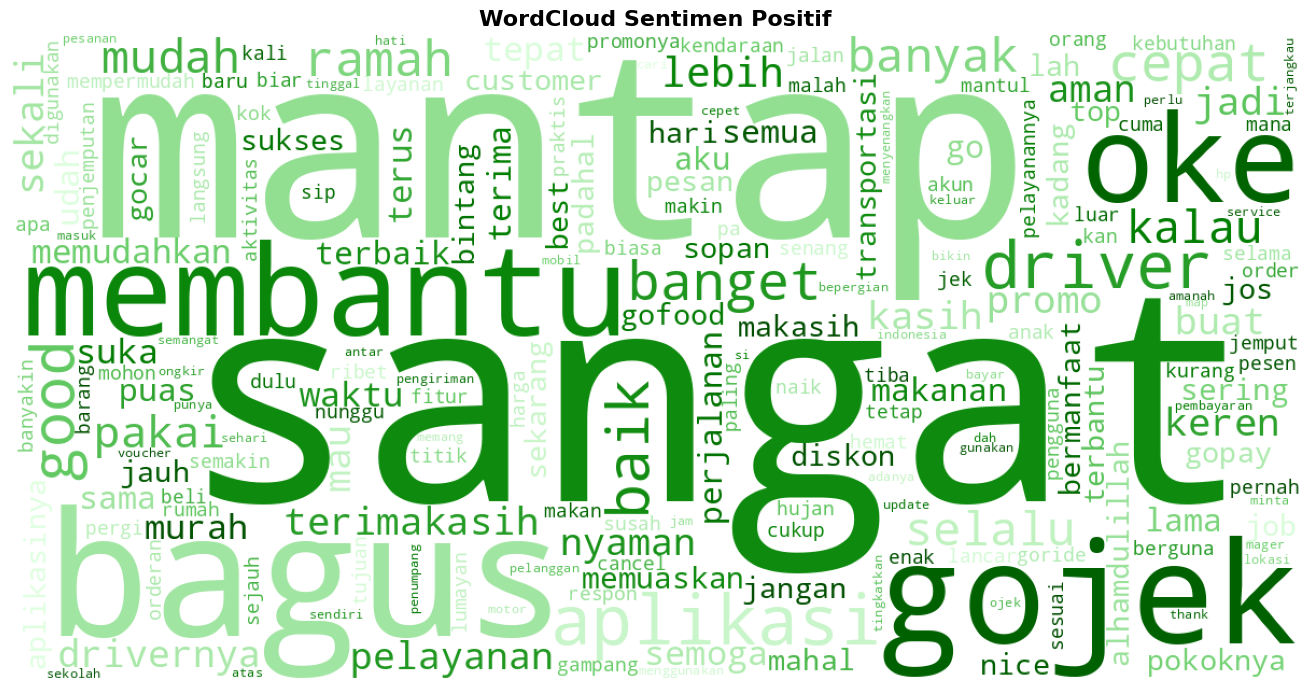

In [70]:
# =======================================================
# SEL 32 : WORDCLOUD POSITIF
# =======================================================

from matplotlib.colors import LinearSegmentedColormap

positif_text = " ".join(
    df[
        df["label"] == 2
    ]["content_visualisasi"].astype(str)
)

green_map = LinearSegmentedColormap.from_list(
    "green_map",
    [
        "#DFFFE0",
        "#66CC66",
        "#008000",
        "#004D00"
    ]
)

wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color="white",
    collocations=False,
    max_words=200,
    colormap=green_map
).generate(positif_text)

plt.figure(figsize=(14,7))

plt.imshow(wordcloud)

plt.axis("off")

plt.title(
    "WordCloud Sentimen Positif",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()

plt.savefig(
    f"{PROJECT_DIR}/analysis/wordcloud_positif.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Bigram

,Bigram,Frekuensi
15,sangat membantu,1157
4,customer service,321
19,tiba tiba,290
12,pakai gojek,289
0,aplikasi gojek,252
6,lama banget,248
11,pakai aplikasi,197
18,terima kasih,195
1,aplikasi sangat,189
3,cari driver,185


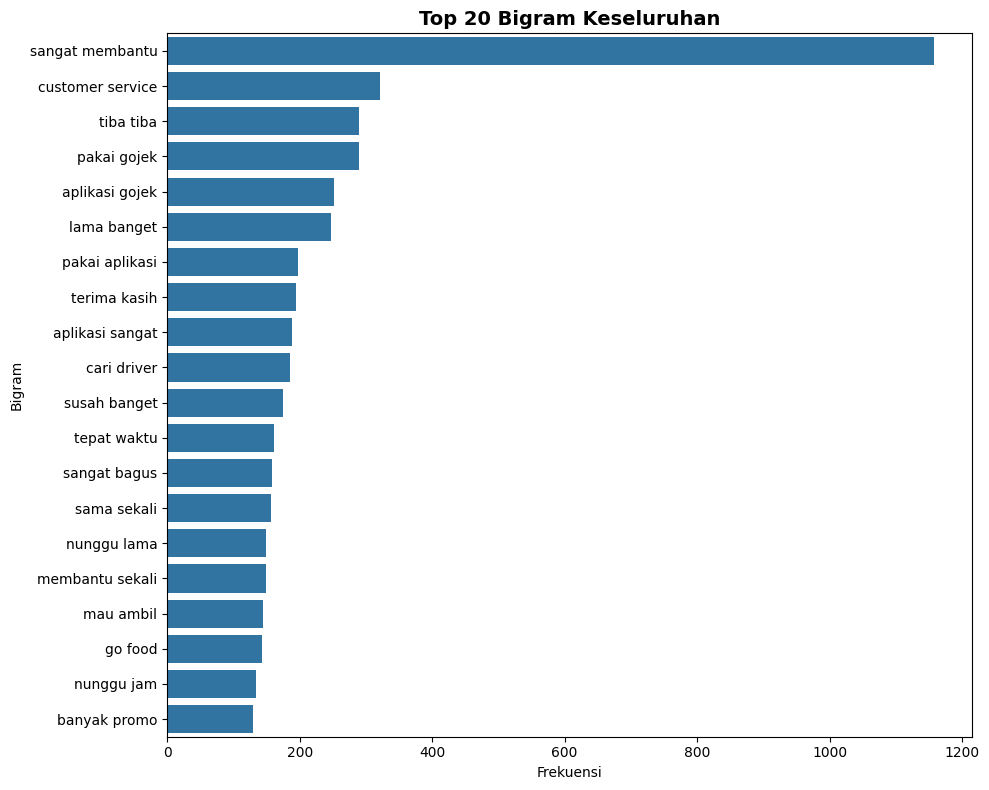

In [82]:
 # =======================================================
# SEL 33 : TOP 20 BIGRAM KESELURUHAN
# =======================================================

from sklearn.feature_extraction.text import CountVectorizer
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

vectorizer = CountVectorizer(
    ngram_range=(2,2),
    max_features=20
)

X = vectorizer.fit_transform(
    df["content_visualisasi"]
)

bigram_counts = pd.DataFrame({
    "Bigram": vectorizer.get_feature_names_out(),
    "Frekuensi": X.toarray().sum(axis=0)
})

bigram_counts = bigram_counts.sort_values(
    by="Frekuensi",
    ascending=False
)

display(
    bigram_counts.sort_values(
        by="Frekuensi",
        ascending=False
    )
)

plt.figure(figsize=(10,8))

sns.barplot(
    data=bigram_counts,
    x="Frekuensi",
    y="Bigram"
)

plt.title(
    "Top 20 Bigram Keseluruhan",
    fontsize=14,
    fontweight="bold"
)

plt.tight_layout()

plt.savefig(
    f"{PROJECT_DIR}/analysis/bigram_keseluruhan.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

,Bigram,Frekuensi
2,customer service,275
18,tiba tiba,243
6,lama banget,208
1,cari driver,153
15,sama sekali,136
16,susah banget,135
12,pakai aplikasi,126
8,nunggu jam,124
13,pakai gojek,124
9,nunggu lama,119


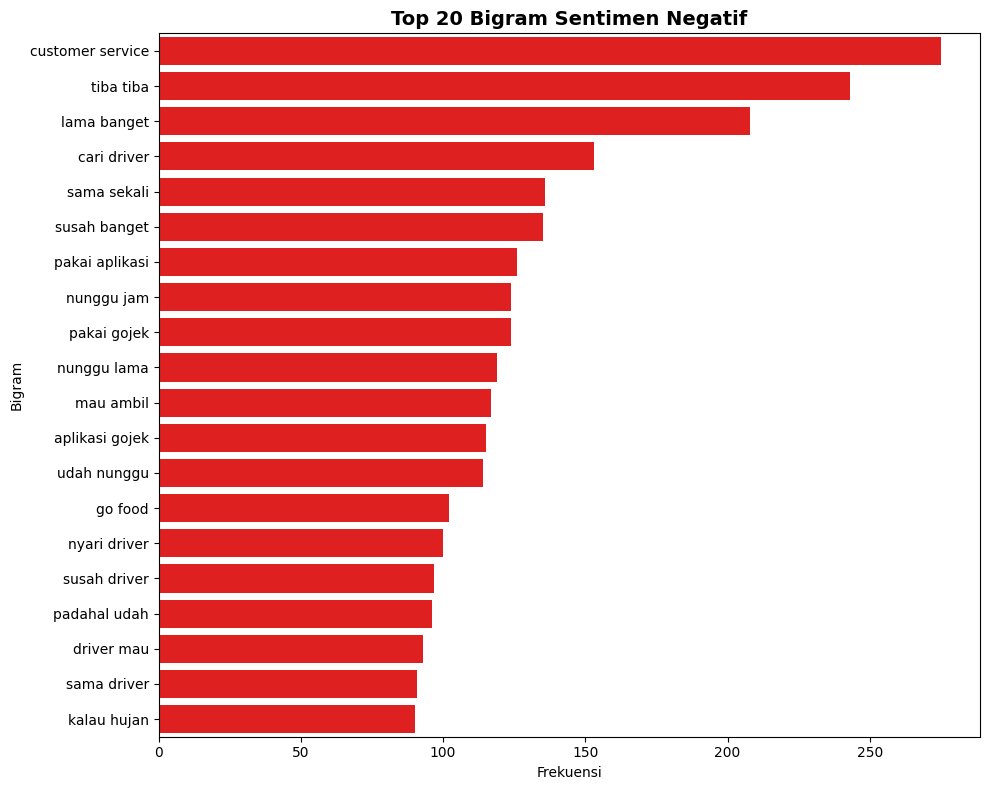

In [76]:
# =======================================================
# SEL 34 : TOP 20 BIGRAM NEGATIF
# =======================================================

negatif_text = df[
    df["label"] == 0
]["content_visualisasi"]

vectorizer = CountVectorizer(
    ngram_range=(2,2),
    max_features=20
)

X = vectorizer.fit_transform(
    negatif_text
)

bigram_negatif = pd.DataFrame({
    "Bigram": vectorizer.get_feature_names_out(),
    "Frekuensi": X.toarray().sum(axis=0)
})

bigram_negatif = bigram_negatif.sort_values(
    by="Frekuensi",
     ascending=False
)

display(
    bigram_negatif.sort_values(
        by="Frekuensi",
        ascending=False
    )
)

plt.figure(figsize=(10,8))

sns.barplot(
    data=bigram_negatif,
    x="Frekuensi",
    y="Bigram",
    color="#FF0000"
)

plt.title(
    "Top 20 Bigram Sentimen Negatif",
    fontsize=14,
    fontweight="bold"
)

plt.tight_layout()

plt.savefig(
    f"{PROJECT_DIR}/analysis/bigram_negatif.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

,Bigram,Frekuensi
8,lama banget,28
1,customer service,20
10,mau ambil,20
18,tiba tiba,19
0,cari driver,17
2,driver gojek,17
16,susah banget,17
15,sering banget,14
6,gojek plus,14
13,pakai gojek,14


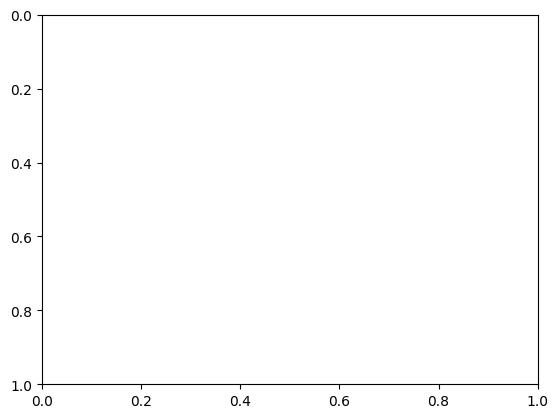

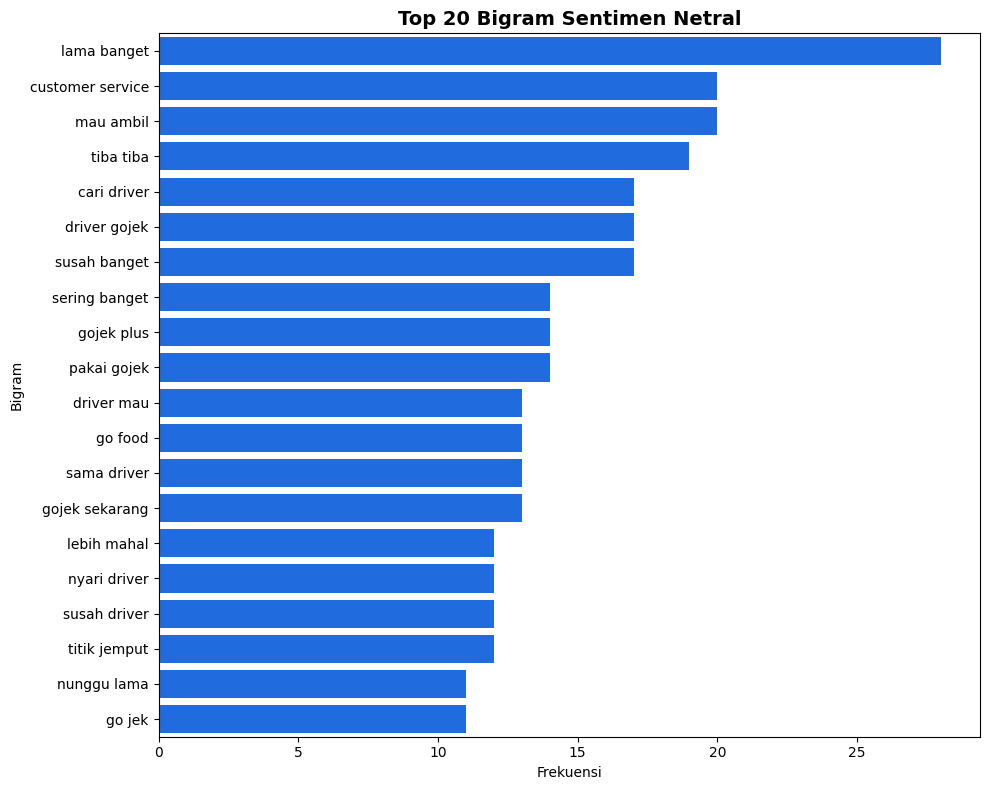

In [77]:
# =======================================================
# SEL 35 : TOP 20 BIGRAM NETRAL
# =======================================================

netral_text = df[
    df["label"] == 1
]["content_visualisasi"]

vectorizer = CountVectorizer(
    ngram_range=(2,2),
    max_features=20
)

X = vectorizer.fit_transform(
    netral_text
)

bigram_netral = pd.DataFrame({
    "Bigram": vectorizer.get_feature_names_out(),
    "Frekuensi": X.toarray().sum(axis=0)
})

bigram_netral = bigram_netral.sort_values(
    by="Frekuensi",
     ascending=False
)

display(
    bigram_netral.sort_values(
        by="Frekuensi",
        ascending=False
    )
)

plt.gca().invert_yaxis()

plt.figure(figsize=(10,8))

sns.barplot(
    data=bigram_netral,
    x="Frekuensi",
    y="Bigram",
    color="#0066FF"
)

plt.title(
    "Top 20 Bigram Sentimen Netral",
    fontsize=14,
    fontweight="bold"
)

plt.tight_layout()

plt.savefig(
    f"{PROJECT_DIR}/analysis/bigram_netral.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

,Bigram,Frekuensi
15,sangat membantu,1136
18,terima kasih,167
2,aplikasi sangat,163
12,sangat bagus,152
11,pakai gojek,151
9,membantu sekali,147
17,tepat waktu,144
1,aplikasi gojek,127
4,banyak promo,123
8,good job,105


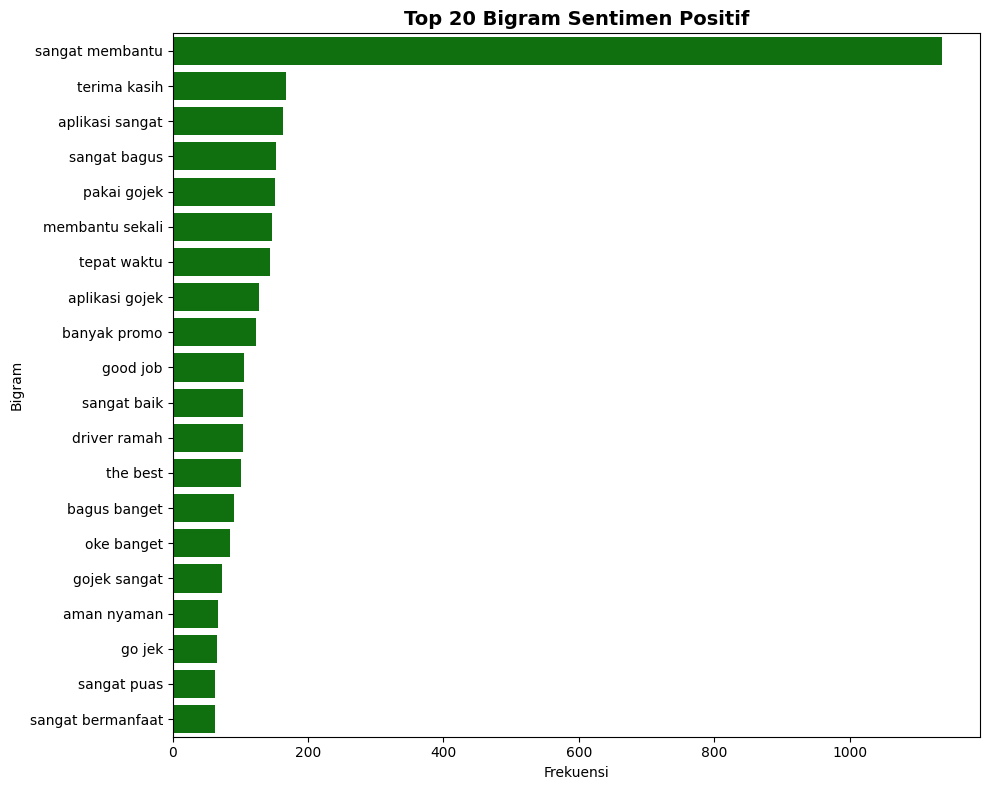

In [79]:
# =======================================================
# SEL 36 : TOP 20 BIGRAM POSITIF
# =======================================================

positif_text = df[
    df["label"] == 2
]["content_visualisasi"]

vectorizer = CountVectorizer(
    ngram_range=(2,2),
    max_features=20
)

X = vectorizer.fit_transform(
    positif_text
)

bigram_positif = pd.DataFrame({
    "Bigram": vectorizer.get_feature_names_out(),
    "Frekuensi": X.toarray().sum(axis=0)
})

bigram_positif = bigram_positif.sort_values(
    by="Frekuensi",
    ascending=False
)

display(
    bigram_positif.sort_values(
        by="Frekuensi",
        ascending=False
    )
)

plt.figure(figsize=(10,8))

sns.barplot(
    data=bigram_positif,
    x="Frekuensi",
    y="Bigram",
    color="#008000"
)

plt.title(
    "Top 20 Bigram Sentimen Positif",
    fontsize=14,
    fontweight="bold"
)

plt.tight_layout()

plt.savefig(
    f"{PROJECT_DIR}/analysis/bigram_positif.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

=== DISTRIBUSI PANJANG ULASAN ===


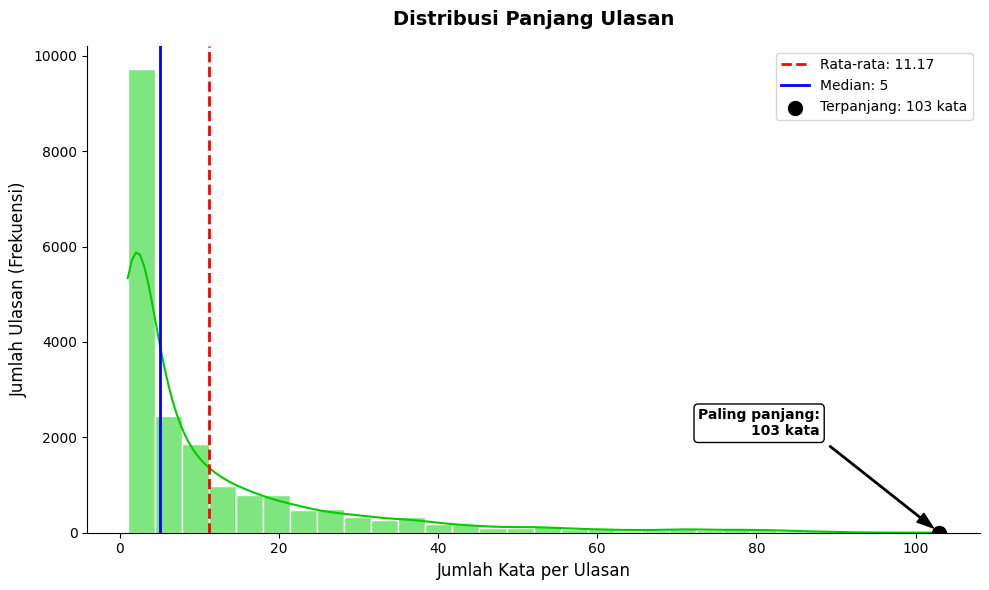

Hasil Analisis: Ulasan terpanjang terdiri dari 103 kata.

=== RINGKASAN STATISTIK PANJANG ULASAN ===
Rata-rata panjang ulasan : 11.17 kata
Ulasan terpendek         : 1 kata
Ulasan terpanjang        : 103 kata
Nilai tengah (Median)    : 5 kata
Simpangan baku           : 15.44


,Nilai
count,19794.000000
mean,11.172679
std,15.437882
min,1.000000
25%,2.000000
50%,5.000000
75%,14.000000
max,103.000000


In [83]:
# =======================================================
# SEL 37 : DISTRIBUSI PANJANG ULASAN
# =======================================================

import matplotlib.pyplot as plt
import seaborn as sns

# Hitung jumlah kata tiap ulasan

df["token_count"] = (
    df["content_normalisasi"]
    .astype(str)
    .str.split()
    .apply(len)
)

print("=== DISTRIBUSI PANJANG ULASAN ===")

plt.figure(figsize=(10,6))

# Histogram

sns.histplot(
    df["token_count"],
    bins=30,
    kde=True,
    color="#00CC00",
    edgecolor="white"
)

# Statistik

mean_val = df["token_count"].mean()

median_val = df["token_count"].median()

max_val = df["token_count"].max()

# Garis rata-rata

plt.axvline(
    mean_val,
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Rata-rata: {mean_val:.2f}"
)

# Garis median

plt.axvline(
    median_val,
    color="blue",
    linestyle="-",
    linewidth=2,
    label=f"Median: {median_val:.0f}"
)

# Titik ulasan terpanjang

plt.scatter(
    max_val,
    0,
    color="black",
    s=100,
    label=f"Terpanjang: {max_val} kata",
    zorder=5
)

# Anotasi

plt.annotate(
    f"Paling panjang:\n{max_val} kata",
    xy=(max_val, 0),
    xytext=(
        max_val - 15,
        plt.gca().get_ylim()[1] * 0.2
    ),
    arrowprops=dict(
        facecolor="black",
        shrink=0.05,
        width=1,
        headwidth=8
    ),
    ha="right",
    fontsize=10,
    fontweight="bold",
    bbox=dict(
        boxstyle="round,pad=0.3",
        fc="white",
        ec="black",
        lw=1
    )
)

plt.title(
    "Distribusi Panjang Ulasan",
    fontsize=14,
    fontweight="bold",
    pad=15
)

plt.xlabel(
    "Jumlah Kata per Ulasan",
    fontsize=12
)

plt.ylabel(
    "Jumlah Ulasan (Frekuensi)",
    fontsize=12
)

plt.legend()

sns.despine()

plt.tight_layout()

plt.savefig(
    f"{PROJECT_DIR}/analysis/distribusi_panjang_ulasan.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    f"Hasil Analisis: Ulasan terpanjang terdiri dari {max_val} kata."
)

# =====================================================
# RINGKASAN STATISTIK
# =====================================================

stats = df["token_count"].describe()

print("\n=== RINGKASAN STATISTIK PANJANG ULASAN ===")

print(
    f"Rata-rata panjang ulasan : {stats['mean']:.2f} kata"
)

print(
    f"Ulasan terpendek         : {stats['min']:.0f} kata"
)

print(
    f"Ulasan terpanjang        : {stats['max']:.0f} kata"
)

print(
    f"Nilai tengah (Median)    : {stats['50%']:.0f} kata"
)

print(
    f"Simpangan baku           : {stats['std']:.2f}"
)

display(
    stats.to_frame(
        name="Nilai"
    )
)

In [81]:
# =======================================================
# SEL 38 : RINGKASAN DATASET FINAL
# =======================================================

summary_df = pd.DataFrame({

    "Informasi": [

        "Total Data",

        "Jumlah Negatif",
        "Jumlah Netral",
        "Jumlah Positif",

        "Rating 1",
        "Rating 2",
        "Rating 3",
        "Rating 4",
        "Rating 5",

        "Rata-rata Panjang Ulasan",
        "Median Panjang Ulasan",
        "Minimum Panjang Ulasan",
        "Maksimum Panjang Ulasan"

    ],

    "Nilai": [

        len(df),

        (df["label"] == 0).sum(),
        (df["label"] == 1).sum(),
        (df["label"] == 2).sum(),

        (df["score"] == 1).sum(),
        (df["score"] == 2).sum(),
        (df["score"] == 3).sum(),
        (df["score"] == 4).sum(),
        (df["score"] == 5).sum(),

        round(df["jumlah_kata"].mean(),2),
        int(df["jumlah_kata"].median()),
        int(df["jumlah_kata"].min()),
        int(df["jumlah_kata"].max())
    ]
})

display(summary_df)

summary_df.to_csv(
    f"{PROJECT_DIR}/analysis/dataset_summary.csv",
    index=False
)

print(
    "✅ Ringkasan dataset berhasil disimpan"
)

,Informasi,Nilai
0,Total Data,19794.00
1,Jumlah Negatif,6122.00
2,Jumlah Netral,757.00
3,Jumlah Positif,12915.00
4,Rating 1,5321.00
5,Rating 2,801.00
6,Rating 3,757.00
7,Rating 4,951.00
8,Rating 5,11964.00
9,Rata-rata Panjang Ulasan,11.17


✅ Ringkasan dataset berhasil disimpan


# Reload Data EDA

In [ ]:
df = pd.read_csv("https://raw.githubusercontent.com/Miranita-ar/Skripsi-Gojek-App-Review/refs/heads/main/Data/data_preprocessed_multiclass.csv")

rating_before = pd.read_csv(
    rating_before_url,
    index_col=0
)

label_before = pd.read_csv(
    label_before_url,
    index_col=0
)

rating_after = pd.read_csv(
    rating_after_url,
    index_col=0
)

label_after = pd.read_csv(
    label_after_url,
    index_col=0
)

In [47]:
# =======================================================
# RELOAD DATA EDA DARI GITHUB
# =======================================================

preprocessed_url = "https://raw.githubusercontent.com/Miranita-ar/Skripsi-Gojek-App-Review/refs/heads/main/Data/data_preprocessed_multiclass.csv"

rating_before_url = "https://raw.githubusercontent.com/Miranita-ar/Skripsi-Gojek-App-Review/refs/heads/main/Data/rating_before.csv"

label_before_url = "https://raw.githubusercontent.com/Miranita-ar/Skripsi-Gojek-App-Review/refs/heads/main/Data/label_before.csv"

rating_after_url = "https://raw.githubusercontent.com/Miranita-ar/Skripsi-Gojek-App-Review/refs/heads/main/Data/rating_after.csv"

label_after_url = "https://raw.githubusercontent.com/Miranita-ar/Skripsi-Gojek-App-Review/refs/heads/main/Data/label_after.csv"


df = pd.read_csv(
    preprocessed_url
)

rating_before = pd.read_csv(
    rating_before_url,
    index_col=0
)

label_before = pd.read_csv(
    label_before_url,
    index_col=0
)

rating_after = pd.read_csv(
    rating_after_url,
    index_col=0
)

label_after = pd.read_csv(
    label_after_url,
    index_col=0
)

print("✅ Seluruh data EDA berhasil di-load")

✅ Seluruh data EDA berhasil di-load


In [ ]:
pd.read_csv(raw_github_url)

In [48]:
# =======================================================
# RELOAD DATA EDA DARI GITHUB
# =======================================================

preprocessed_url = "https://raw.githubusercontent.com/Miranita-ar/Skripsi-Gojek-App-Review/refs/heads/main/Data/data_preprocessed_multiclass.csv"

rating_before_url = "https://raw.githubusercontent.com/Miranita-ar/Skripsi-Gojek-App-Review/refs/heads/main/Data/rating_before.csv"

label_before_url = "https://raw.githubusercontent.com/Miranita-ar/Skripsi-Gojek-App-Review/refs/heads/main/Data/label_before.csv"

rating_after_url = "https://raw.githubusercontent.com/Miranita-ar/Skripsi-Gojek-App-Review/refs/heads/main/Data/rating_after.csv"

label_after_url = "https://raw.githubusercontent.com/Miranita-ar/Skripsi-Gojek-App-Review/refs/heads/main/Data/label_after.csv"


df = pd.read_csv(
    preprocessed_url
)

rating_before = pd.read_csv(
    rating_before_url,
    index_col=0
)

label_before = pd.read_csv(
    label_before_url,
    index_col=0
)

rating_after = pd.read_csv(
    rating_after_url,
    index_col=0
)

label_after = pd.read_csv(
    label_after_url,
    index_col=0
)

print(df.shape)

display(df.head())
display(rating_before)
display(label_before)
display(rating_after)
display(label_after)

(19794, 15)


,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion,label,content_lower_case,content_clean,content_normalisasi
0,5adef64a-687b-44cb-ae83-fccac29af5f8,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"saya sudah memakai aplikasi gojek 4 tahun,alha...",5,0,5.47.1,2026-02-03 00:57:36,NaN,NaN,5.47.1,2,"saya sudah memakai aplikasi gojek 4 tahun,alha...",saya sudah memakai aplikasi gojek 4 tahun alha...,saya sudah memakai aplikasi gojek 4 tahun alha...
1,ee4c68a5-56ba-4460-a302-8f6c1fe3b919,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,jarang ada diskon,5,0,5.48.2,2026-02-03 00:51:32,NaN,NaN,5.48.2,2,jarang ada diskon,jarang ada diskon,jarang ada diskon
2,a1487729-8a06-4fb9-a99e-762150ba7438,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"makin berat aja apk, muter mulu mau beli tiket...",1,0,5.39.1,2026-02-03 00:37:37,"Hai Kak @Now You See Me Sony Handoko, mohon ma...",2026-02-03 01:46:54,5.39.1,0,"makin berat aja apk, muter mulu mau beli tiket...",makin berat aja apk muter mulu mau beli tiket krl,makin berat aja aplikasi muter terus mau beli ...
3,37bb5ff1-22d2-49aa-afa9-4c0a88564a8e,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,aplikasi terbaik,5,0,5.47.1,2026-02-03 00:27:07,NaN,NaN,5.47.1,2,aplikasi terbaik,aplikasi terbaik,aplikasi terbaik
4,06afd47c-c6be-4839-9931-9d90b918b039,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"Di kasih limit di gopay pinjam 200rb,pengajuan...",2,0,5.48.2,2026-02-03 00:24:42,"Hai Kak Wirijaf, mohon maaf atas ketidaknyaman...",2026-02-03 01:42:50,5.48.2,0,"di kasih limit di gopay pinjam 200rb,pengajuan...",di kasih limit di gopay pinjam 200rb pengajuan...,di kasih limit di gopay pinjam 200 ribu pengaj...


,count
score,
1,5327
2,802
3,759
4,958
5,12154


,count
label,
0,6129
1,759
2,13112


,count
score,
1,5321
2,801
3,757
4,951
5,11964


,count
label,
0,6122
1,757
2,12915
